# BEE 4310/6310: Environmental Statistics and Learning  <br> Assignment #5 Part 2 (5 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

**Techniques and Topics:** 
- Recurrent Neural Networks

In this assignment, you will build and apply a simple recurrent neural network (RNN) to model stream temperature from air temperature data. The problems below guide you through implementing the core components of an RNN from scratch, testing those components on a small synthetic dataset, and then training the model on observed environmental data. You will use the trained network to generate predictions and evaluate model performance on held-out test data.

<img align="right" src="stream_temperature.jpg" width="300"/>

Before beginning, import the following packages: 
- numpy
- pandas
- matplotlib.pyplot
- MinMaxScaler from sklearn.preprocessing
- train_test_split from sklearn.model_selection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

1. In this problem, you will build the core functions for a simple recurrent neural network (RNN) from scratch using NumPy. The network will use a tanh hidden-state update and will produce a single output at the final time step of each input sequence. Note: Some starter code will be provided for this problem. 

    For an input sequence $x_1$,...,$x_T$ of sequence length T, the RNN should follow these core equations:

    $h_t$ = tanh($h_{t-1}$ $W_{hh}$ + $x_t$ $W_{xh}$ + $b_h$)

    $\hat{y_t}$ = $h_t$ $W_{hy}$ + $b_y$

    Where: 

    - $x_t$ is the input at time step *t*
    - $h_t$ is the hidden state at time step *t*
    - $\hat{y_t}$ is the predicted output based on the final hidden state


- (a) Initialize the model parameters

    Write a function init_params_RNN(input_dim, hidden_dim, output_dim) that takes as input the number of features (input_dim), the hidden dimension (hidden_dim), and the output dimension (output_dim), and initializes:
    - $W_{xh}$
    - $W_{hh}$
    - $b_h$
    - $W_{hy}$    
    - $b_y$    

    Initialize the weight matrices with small random values, e.g., 0.1*np.random.randn(d1,d2), where d1 and d2 are the appropriate dimensions for each weight matrix. When thinking through these dimensions, refer to the core RNN equations above, and assume that the input X to the forward pass will have shape (batch_size, seq_len, input_dim). That is, X will be a numpy array with the first dimension equal to the number of samples in the batch, second dimension equal to the number of lookback values in X that compose the input sequence, and third dimension equal to the number of features in X. 
    
    Initialize the bias terms to zero. Use np.zeros((1, d)), where d is the appropriate dimension for each bias term. This formulation ensures the bias term broadcasts correctly across the batch dimension. 


- (b) Write the activation function

    - Write functions called tanh(x) and dtanh(x) for the tanh activation and its derivative.
    

- (c) Write the forward pass

    - Write a function called forward_RNN(Xb, Wxh, Whh, bh, Why, by) that performs a forward pass through the RNN for one batch of input sequences. Here, Xb is a 'mini-batch' of inputs of shape shape (batch_size, seq_len, input_dim) drawn from the full set of inputs X. 
 

     - Your function should:

        - infer the batch size, sequence length, and hidden layer dimension from the input arguments to this function
        - initialize the hidden state at time 0 as a 2D numpy array of zeros, with dimension (batch_size, hidden_dim)
        - loop through the sequence one time step at a time
        - compute and store the hidden state at each time step
        - compute the final output from the last hidden state
        - return a dictionary containing:
            - the batch input
            - the hidden states
            - the final output



- (d) Write the loss function
       
    - Write a function called mse_loss_RNN(out, yb) that computes the mean squared error between the network output and the target values yb for the current mini-batch.



- (e) Write the backward pass
        
    - Write a function called backward_RNN(outcomes, yb, Wxh, Whh, bh, Why, by) that computes the gradients of the loss with respect to all parameters using backpropagation through time.
    - Return the gradients in a dictionary with keys corresponding to each parameter.
    - Note: This function is provided to you in its entirety



- (f) Write the gradient decent step
    
    - Write a function called step_RNN(Wxh, Whh, bh, Why, by, grads, lr) that updates the parameters using gradient descent.



In [9]:
#Initialization
def init_params_RNN(input_dim, hidden_dim, output_dim):
    #Initialize weights and biases for a simple tanh RNN
    Wxh = 0.1*np.random.randn(input_dim,hidden_dim)
    Whh = 0.1*np.random.randn(hidden_dim,hidden_dim)
    bh  = np.zeros((1, hidden_dim))
    Why = 0.1*np.random.randn(hidden_dim,output_dim)
    by  = np.zeros((1, output_dim))
    return Wxh, Whh, bh, Why, by


#Tanh activation and derivative functions
def tanh(x): 
    return np.tanh(x)
def dtanh(x): 
    return 1.-np.tanh(x)**2

#Forward pass
def forward_RNN(Xb, Wxh, Whh, bh, Why, by):
    #Forward pass through RNN for one batch.
    #Xb: (batch_size, seq_len, input_dim)
    #Returns:
    #    out: final output (batch_size, output_dim)
    #    hs: list of hidden states (for backprop)

    #<infer batch_size, seq_length, and hidden_dim from arguments passed to this function>    

    #<initialize the hidden state as a 2D numpy array of zeros, with size (batch_size, hidden_dim)>

    #<create an empty list, hs, to store the hidden states across the sequence>

    #<create a for loop that cycles through the sequence length,
    # computes the hidden state at each time step, 
    # and stores the resulting hidden state in the list hs>
   
    #<calculate the network output, called out, of size (batch_size, output_dim)>

    #return a dictionary of outcomes from the forward pass
    batch_size, seq_len, _  = Xb.shape
    hidden_dim              = Whh.shape[0]
    # Initialize h0 as zeros
    h = np.zeros((batch_size, hidden_dim))
    # Store all hidden states: index 0 = h0, index t = h_t
    hs = [h]
    for t in range(seq_len):
        xt = Xb[:, t, :]                              # (batch_size, input_dim)
        h  = tanh(h @ Whh + xt @ Wxh + bh)           # (batch_size, hidden_dim)
        hs.append(h)
    # Output only from the last hidden state
    y_hat = hs[-1] @ Why + by                         # (batch_size, output_dim)
    outcomes = {'Xb': Xb, 'hs': hs, 'out': y_hat}
    return outcomes


#Loss function
def mse_loss_RNN(out, yb):
    y_hat = out['out']
    loss  = np.mean((y_hat-yb)**2)
    return loss



#Backward pass (this function is provided to you in full)
def backward_RNN(outcomes, yb, Wxh, Whh, bh, Why, by):
    #Backpropagation through time
    Xb, hs, out = outcomes["Xb"], outcomes["hs"], outcomes["out"]
    batch_size, seq_len, _ = Xb.shape

    # Gradients for output layer
    dOut = 2 * (out - yb) / batch_size
    dWhy = hs[-1].T @ dOut
    dby = np.sum(dOut, axis=0, keepdims=True)

    # Gradient flowing into hidden state
    dh_next = dOut @ Why.T

    # Initialize accumulated gradients
    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dbh = np.zeros_like(bh)

    # Backprop through time
    for t in reversed(range(seq_len)):
        h_t = hs[t]
        dh = dh_next
        dt = dh * dtanh(h_t)
        dbh += np.sum(dt, axis=0, keepdims=True)
        dWxh += Xb[:, t, :].T @ dt
        if t > 0:
            dWhh += hs[t-1].T @ dt
        dh_next = dt @ Whh.T

    grads = {"dWxh": dWxh, "dWhh": dWhh, "dbh": dbh, "dWhy": dWhy, "dby": dby}
    return grads



#Parameter update
def step_RNN(Wxh, Whh, bh, Why, by, grads, lr=0.01):
    #<apply gradient descent step>
    Wxh = Wxh - grads['dWxh']*lr
    Whh = Whh - grads['dWhh']*lr
    bh  = bh  - grads['dbh']*lr
    Why = Why - grads['dWhy']*lr
    by  = by  - grads['dby']*lr
    return Wxh, Whh, bh, Why, by


2. **(2 points)** In this problem, we will test the functions above on a small dummy dataset before applying your RNN to the real dataset. In the code block below, I provide dummy predictors X and target values y. Each input sample is a sequence of length 3 with one predictor at each time step, and each target value is the sum of the values in that sequence.

    In the data provided:
    - the batch size is 4, since there are 4 observations in both X_dummy and y_dummy
    - the sequence length is 3, since we have 3 sequential values of the predictor that the RNN will ingest
    - the input dimension is 1, since there is only one predictor variable
    - the output dimension is 1, since there is a single target variable
    - In summary, the size of X_dummy is (batch_size, seq_length, input_dim) and the size of y_dummy is (batch_size,1). This is consistent with the functions you wrote above. 

    Using this dummy dataset:

    - initialize the RNN parameters
        - *assume a hidden state size of 4 in your RNN*
    - run a forward pass
    - calculate the loss
    - run the backward pass
    - perform a gradient descent update, using a learning rate of 0.01
    - repeat these steps for 500 iterations, tracking the loss at each step

    **Plot the loss over iterations, and report the final loss at the end of the 500 iterations**

    To confirm your functions from Problem (1) are working properly, note that your results should show a loss of 0.05 or below. 

    *HINT: to debug your code, check that the output and gradient dimensions are consistent with the parameter dimensions*


In [13]:
### ------  provided dummy variables ----- ###
X_dummy = np.array([
    [[1.0], [2.0], [3.0]],
    [[2.0], [1.0], [0.0]],
    [[0.5], [0.5], [0.5]],
    [[3.0], [2.0], [1.0]]
])

y_dummy = np.array([
    [6.0],
    [3.0],
    [1.5],
    [6.0]
])

print(X_dummy.shape)
print(y_dummy.shape)

### train RNN model
input_dim, hidden_dim, output_dim = 1,4,1
n_iters = 500
lr = 0.01
Wxh, Whh, bh, Why, by = init_params_RNN(input_dim, hidden_dim, output_dim)
loss_all = []
for iter in range(n_iters):
    outcomes = forward_RNN(X_dummy, Wxh, Whh, bh, Why, by)
    loss = mse_loss_RNN(outcomes, y_dummy)
    loss_all.append(loss)
    grads = backward_RNN(outcomes, y_dummy, Wxh, Whh, bh, Why, by)
    Wxh, Whh, bh, Why, by = step_RNN(Wxh, Whh, bh, Why, by, grads, lr=0.01)
print(f"Initial Loss : {loss_all[0]:.4f}")
print(f"Final Loss   : {loss_all[-1]:.4f}")
print(f"Target met (loss ≤ 0.05): {loss_all[-1] <= 0.05}")

(4, 3, 1)
(4, 1)
Initial Loss : 20.9049
Final Loss   : 0.0269
Target met (loss ≤ 0.05): True


3. **(2 points)** In this problem, you will apply the simple recurrent neural network (RNN) you developed in Problem 2 to predict daily maximum stream temperature from recent air temperature observations in the Esopus Creek, NY, an important water supply source for NYC.

    You will use the file stream_temperature_esopus.csv, which contains:

    - tmean_air_F: daily mean air temperature (°F)
    - tmax_stream_C: daily maximum stream temperature (°C)

    The goal is to use a short sequence of recent air temperatures to predict stream temperature on the final day of that sequence.

- (a) Load and organize the data

    Load stream_temperature_esopus.csv as a pandas dataframe. Then define:

    - x as the predictor series, using tmean_air_F
    - y as the target series, using tmax_stream_C

    *Make sure to store both x and y as 2D NumPy arrays with one column.*   


- (b) Split the data into training and testing sets

    - Using train_test_split, split the data into training and testing sets using a 70% / 30% split, while preserving the original time order of the observations. Do not shuffle the data.

- (c) Scale the data

    - Scale both the predictor and target using MinMaxScaler. Fit each scaler using the training data only, then apply the fitted scalers to both the training and testing sets.

- (d) Create a preprocessing function for sequential input

    - Write a function called preprocess_data(x, y, lookback) that converts the predictor series into overlapping sequences of length lookback.
    - For example, if lookback = 5, the first input sequence should contain the first 5 days of air temperature, and its corresponding target should be the stream temperature on day 5. The second input sequence should contain the 2nd through 6th day of air temperature, and its corresponding target should be the stream temperature on day 6. This pattern continues until the last observation.
    - Your function should return:
        - an input array of shape (n_samples, lookback, input_dim)
        - a target array of shape (n_samples, output_dim)
        - here, n_samples is the total number of samples in the x and y input arguments


- (e) Apply the preprocessing function

    - Using a lookback period of 5, apply your preprocessing function to both the training and testing data.
    - Do this separately for the scaled training data and scaled testing data
    - Ultimately, you should produce 4 variables: x_scaled_tr, y_scaled_tr, x_scaled_tst, y_scaled_tst

- (f) Train the RNN

    - Using the processed, scaled training data, train your RNN with:

        - input_dim = 1
        - hidden_dim = 4
        - output_dim = 1
        - learning rate lr = 0.01
        - epochs = 5000
        - batch_size = 64

    At each epoch, your training procedure should:

    - select a random mini-batch of batch_size training sequences
    - run the forward pass
    - compute the loss
    - compute gradients using backpropagation through time
    - update the parameters
    - store the loss value


- (g) Plot the training loss

    - **Create a plot of loss versus epoch. Label both axes clearly.**



Epoch   500/5000  |  MSE Loss: 0.06089
Epoch  1000/5000  |  MSE Loss: 0.07781
Epoch  1500/5000  |  MSE Loss: 0.05199
Epoch  2000/5000  |  MSE Loss: 0.03630
Epoch  2500/5000  |  MSE Loss: 0.02511
Epoch  3000/5000  |  MSE Loss: 0.01251
Epoch  3500/5000  |  MSE Loss: 0.00906
Epoch  4000/5000  |  MSE Loss: 0.01998
Epoch  4500/5000  |  MSE Loss: 0.02361
Epoch  5000/5000  |  MSE Loss: 0.02198

Final training loss: 0.02198


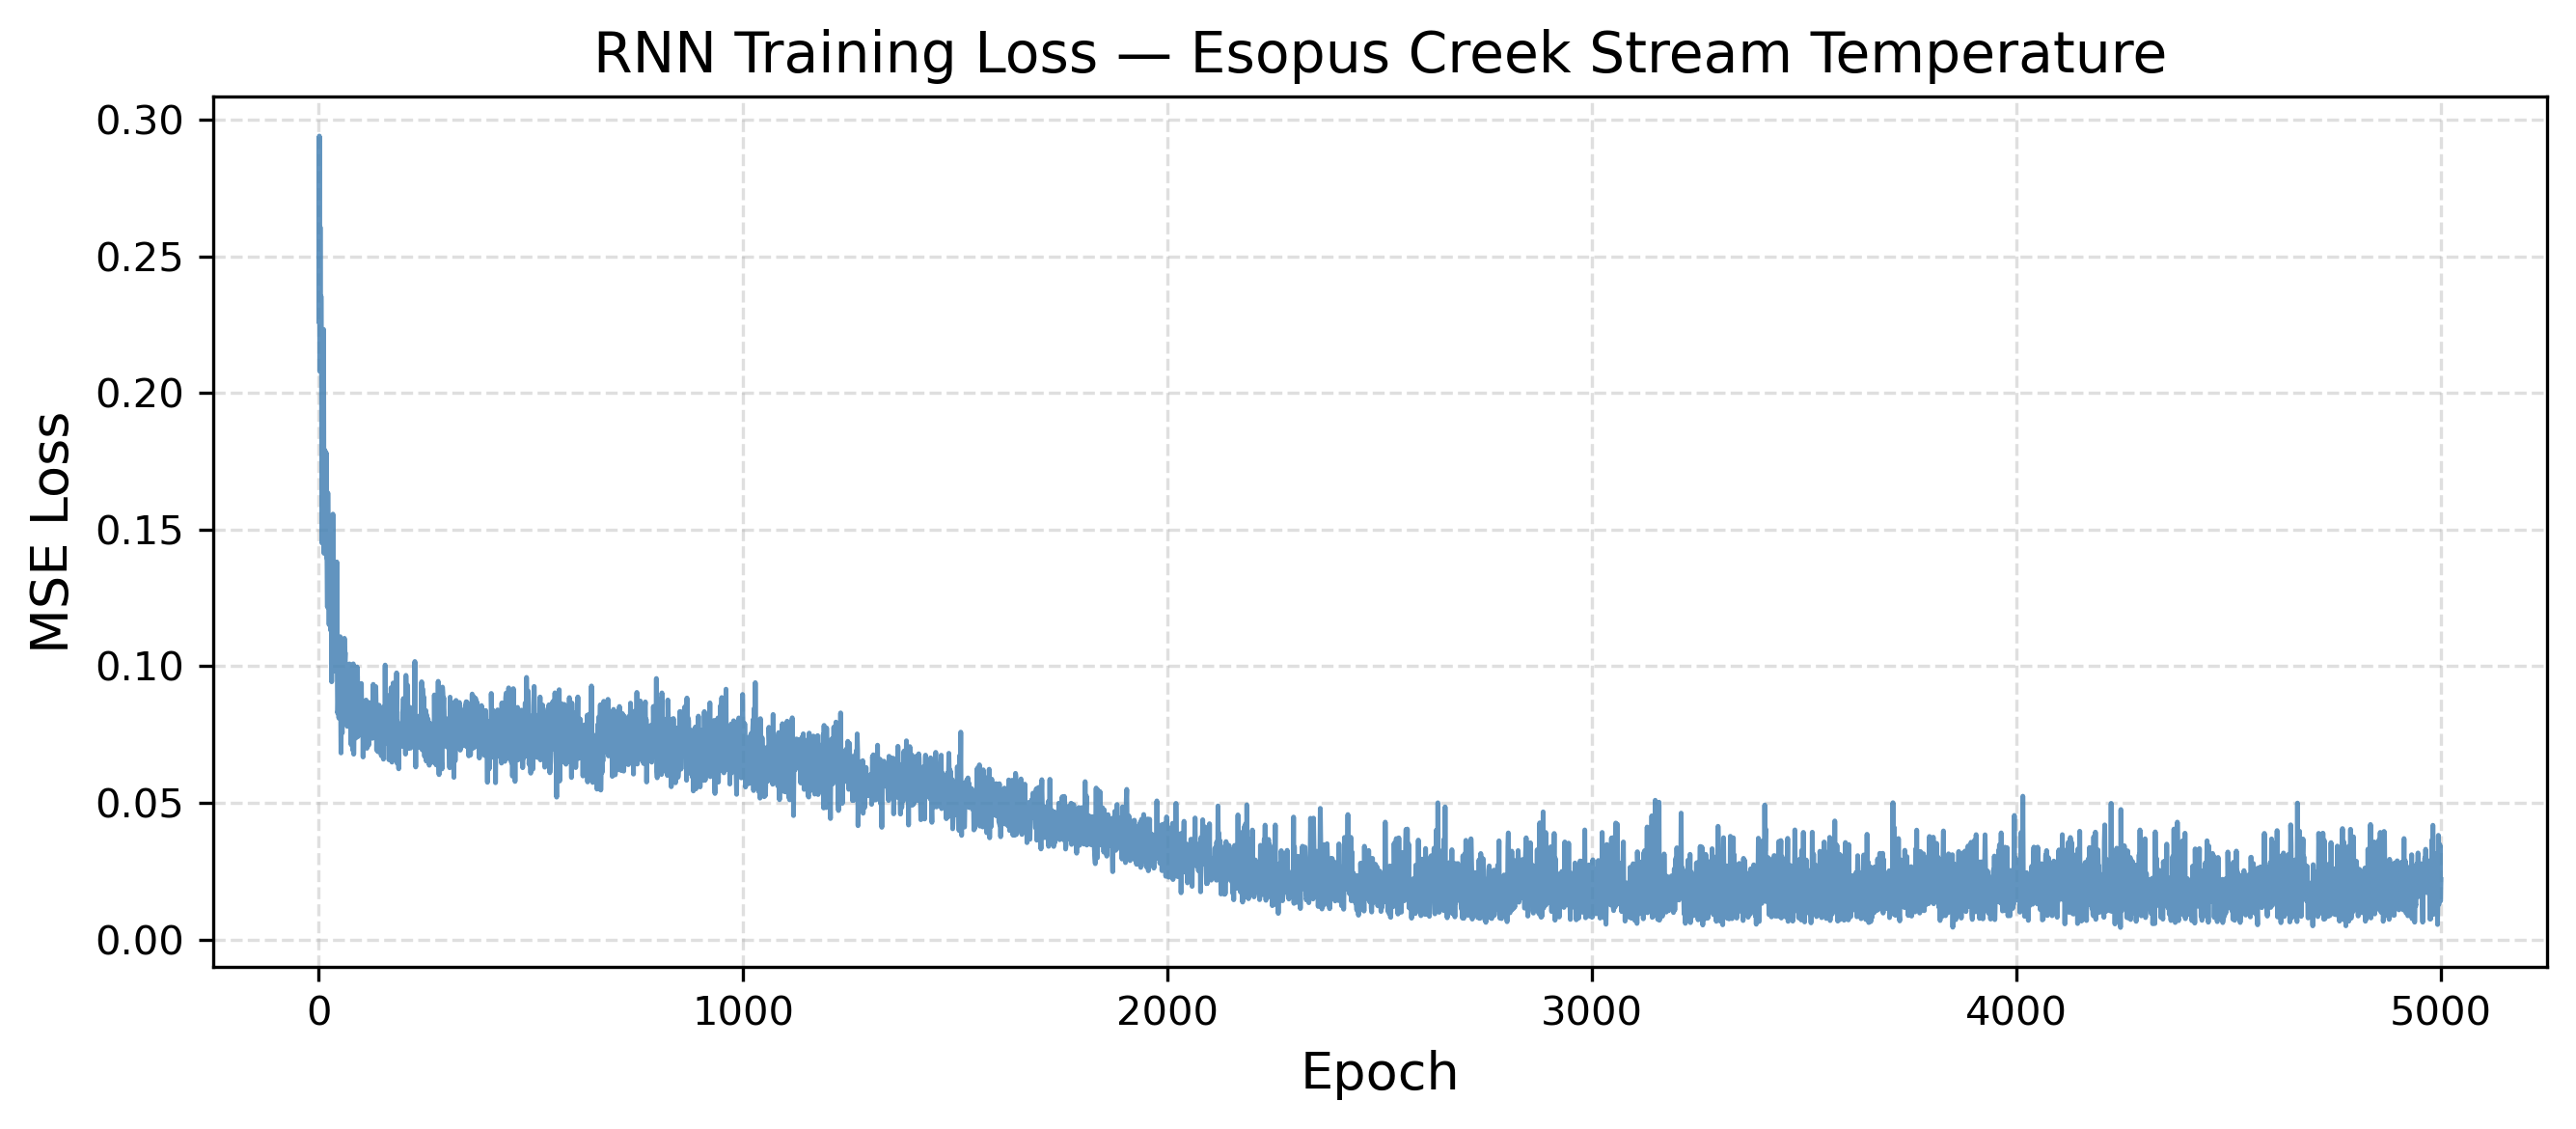

In [20]:
# <read in data>
df = pd.read_csv('stream_temperature_esopus.csv')

# <define inputs x and targets y, making sure they are 2D numpy arrays (not vectors), each with 1 column>
x = df[['tmean_air_F']].to_numpy()    # (N, 1)
y = df[['tmax_stream_C']].to_numpy()  # (N, 1)

# <using train_test_split, split x and y into training and testing. use shuffle=False to preserve temporal order>
x_tr, x_val, y_tr, y_val = train_test_split(x, y, test_size=0.30, shuffle=False)

# <scale using training data only>
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
x_tr_scaled  = scaler_x.fit_transform(x_tr)
x_val_scaled = scaler_x.transform(x_val)
y_tr_scaled  = scaler_y.fit_transform(y_tr)
y_val_scaled = scaler_y.transform(y_val)

# <define preprocessor function for the data>
def preprocess_data(x,y,lookback):
    x_processed, y_processed = [],[]
    # Create overlapping sequences of x and y, called x_processed and y_processed
    for i in range(lookback - 1, len(x)):
        x_processed.append(x[i - lookback + 1 : i + 1, :])
        y_processed.append(y[i,:])
    x_processed = np.array(x_processed)
    y_processed = np.array(y_processed)
    #the output x_processed should be a numpy array of size (n_samples, lookback, input_dim)
    #the output y_processed should be a numpy array of size (n_samples, output_dim)
    return x_processed, y_processed


# <apply the preprocessor function separately to the training data and testing data>
lookback = 5
x_scaled_tr,  y_scaled_tr  = preprocess_data(x_tr_scaled,  y_tr_scaled,  lookback)
x_scaled_val, y_scaled_val = preprocess_data(x_val_scaled, y_val_scaled, lookback)

# <develop and run training loop>
input_dim  = 1
hidden_dim = 4
output_dim = 1
lr         = 0.01
epochs     = 5000
batch_size = 64
np.random.seed(42)
Wxh, Whh, bh, Why, by = init_params_RNN(input_dim, hidden_dim, output_dim)
n_train      = x_scaled_tr.shape[0]
loss_history = []
for epoch in range(epochs):
    # --- random mini-batch selection ---
    idx  = np.random.choice(n_train, size=batch_size, replace=False)
    Xb   = x_scaled_tr[idx]   # (batch_size, lookback, input_dim)
    yb   = y_scaled_tr[idx]   # (batch_size, output_dim)
    # --- forward pass ---
    out = forward_RNN(Xb, Wxh, Whh, bh, Why, by)
    # --- loss ---
    loss  = mse_loss_RNN(out, yb)
    loss_history.append(loss)
    # --- backward pass ---
    grads = backward_RNN(out, yb, Wxh, Whh, bh, Why, by)
    # --- parameter update ---
    Wxh, Whh, bh, Why, by = step_RNN(Wxh, Whh, bh, Why, by, grads, lr)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:>5}/{epochs}  |  MSE Loss: {loss:.5f}")
print(f"\nFinal training loss: {loss_history[-1]:.5f}")

# <plot loss against epoch>
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)
ax.plot(range(1, epochs + 1), loss_history,
        color='steelblue', linewidth=1.2, alpha=0.85)
ax.set_xlabel('Epoch',    fontsize=13)
ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('RNN Training Loss — Esopus Creek Stream Temperature', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('rnn_stream_temp_loss.png', dpi=150)
plt.show()


4. **(1 point)** Using your trained RNN, generate predictions of stream temperature for the test dataset. Convert both the predicted and observed stream temperatures back to their original units (°C). **Then create a scatter plot comparing the predicted values to the observed values, and include a 1:1 reference line. Label both axes clearly.**


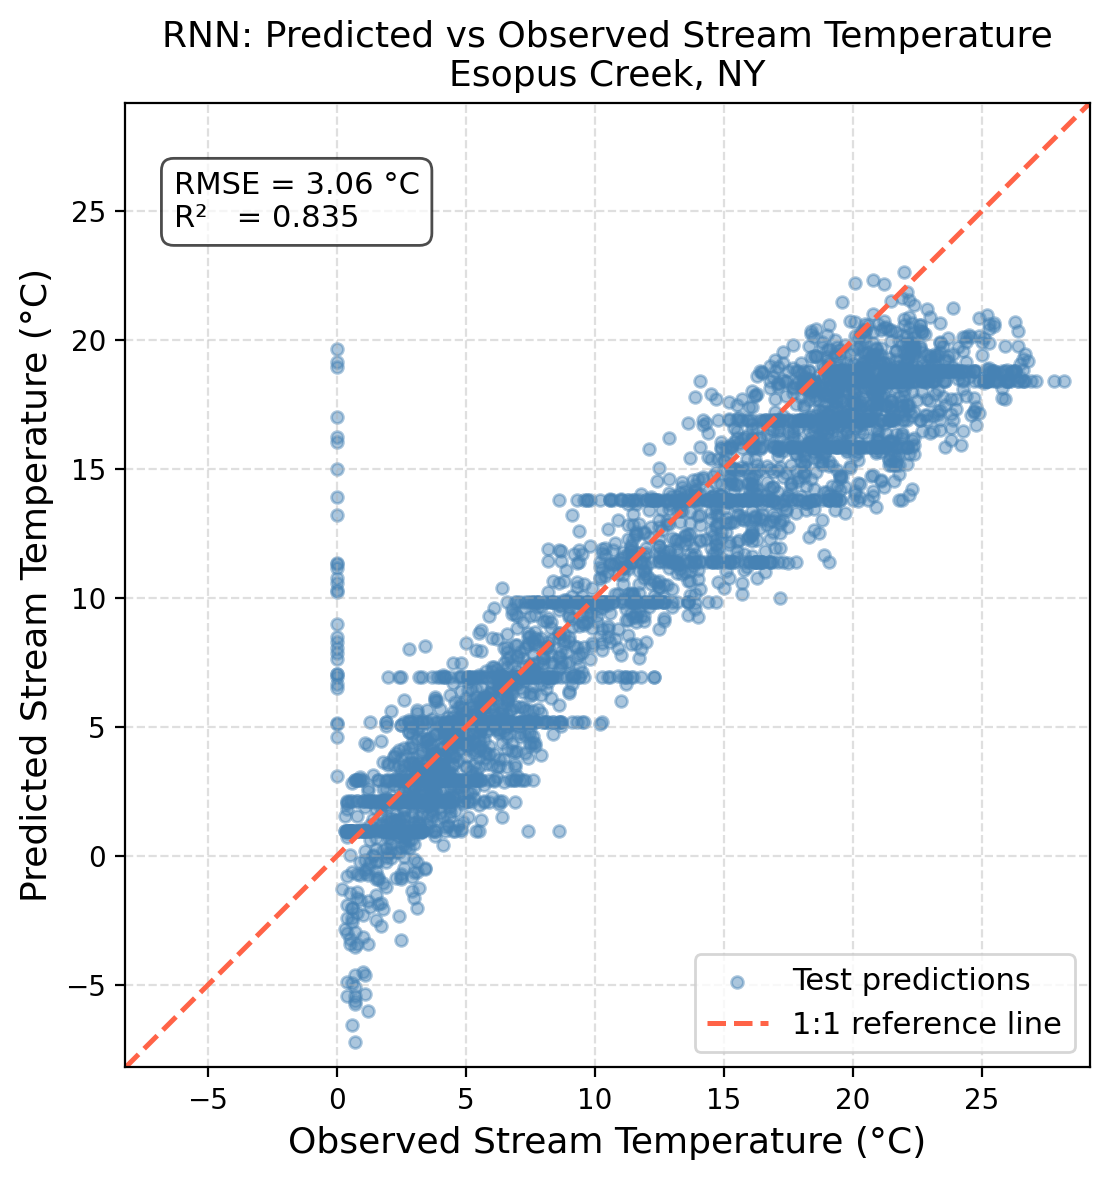

In [21]:
out_tst = forward_RNN(x_scaled_val, Wxh, Whh, bh, Why, by)
y_pred_scaled = out_tst['out']  

y_pred = scaler_y.inverse_transform(y_pred_scaled)   # (n_tst, 1)
y_obs  = scaler_y.inverse_transform(y_scaled_val)    # (n_tst, 1)

# scale plot
mse_test = np.mean((y_pred - y_obs) ** 2)
rmse     = np.sqrt(mse_test)
ss_res   = np.sum((y_obs - y_pred) ** 2)
ss_tot   = np.sum((y_obs - y_obs.mean()) ** 2)
r2       = 1 - ss_res / ss_tot
line_min = min(y_obs.min(), y_pred.min()) - 1
line_max = max(y_obs.max(), y_pred.max()) + 1
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
ax.scatter(y_obs, y_pred,
           color='steelblue', alpha=0.45, s=18, label='Test predictions')
ax.plot([line_min, line_max], [line_min, line_max],
        color='tomato', linewidth=1.8, linestyle='--', label='1:1 reference line')
ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)
ax.set_xlabel('Observed Stream Temperature (°C)',  fontsize=13)
ax.set_ylabel('Predicted Stream Temperature (°C)', fontsize=13)
ax.set_title('RNN: Predicted vs Observed Stream Temperature\nEsopus Creek, NY',
             fontsize=13)
ax.text(0.05, 0.93, f'RMSE = {rmse:.2f} °C\nR²   = {r2:.3f}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('rnn_scatter.png', dpi=150)
plt.show()